## RETAIL SALES ANALYSIS

## Objective

Analyze retail sales data to identify key trends, top-performing products, and regional performance in order to support business decision-making.

## Dataset Overview

The dataset contains information about orders including:
- Order Date
- Region
- Product
- Sales
- Quantity

## Loading Dataset

In [11]:
import pandas as pd
df= pd.read_csv("C:/sales_data.csv",engine="python",encoding="latin1")
df.head()

,Row ID,Order_ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product_Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11-08-2016,11-11-2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11-08-2016,11-11-2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,06-12-2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10-11-2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10-11-2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


## Data Cleaning

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order_ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product_Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [13]:
df.isnull().sum()

Row ID           0
Order_ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product_Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

### Handling Inconsistent Date Formats

The 'Order Date' column contained multiple date formats (e.g., '11-08-2016' and '4/15/2017'), which caused parsing issues.

To resolve this, mixed-format parsing was applied using pandas, ensuring consistent datetime conversion across the dataset.

In [17]:
print(df['Order Date'].head(20))

0     11-08-2016
1     11-08-2016
2     06-12-2016
3     10-11-2015
4     10-11-2015
5     06-09-2014
6     06-09-2014
7     06-09-2014
8     06-09-2014
9     06-09-2014
10    06-09-2014
11    06-09-2014
12     4/15/2017
13    12-05-2016
14    11/22/2015
15    11/22/2015
16    11-11-2014
17     5/13/2014
18     8/27/2014
19     8/27/2014
Name: Order Date, dtype: object


In [20]:
df['Order Date'] = pd.to_datetime(df['Order Date'], format='mixed', dayfirst=True, errors='coerce')
print(df['Order Date'].head(10))

0   2016-08-11
1   2016-08-11
2   2016-12-06
3   2015-11-10
4   2015-11-10
5   2014-09-06
6   2014-09-06
7   2014-09-06
8   2014-09-06
9   2014-09-06
Name: Order Date, dtype: datetime64[ns]


### Feature Engineering: Extracting Month from Order Date

A new feature 'Month' was created by extracting the month from the 'Order Date' column.

This enables time-based analysis to identify monthly sales trends and seasonal patterns.

In [21]:
df['Month'] = df['Order Date'].dt.month

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order_ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   object        
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

## Key Performance Indicators (KPIs)

In [24]:
total_revenue = df["Sales"].sum()
avg_order_value = df["Sales"].mean()
top_region = df.groupby("Region")["Sales"].sum().idxmax()

print("Total Revenue:", total_revenue)
print("Average Order Value:", avg_order_value)
print("Top Region:", top_region)

Total Revenue: 2297200.8603
Average Order Value: 229.85800083049827
Top Region: West


## Visualizations

 ### 1. Sales Over Time (Monthly Trend)

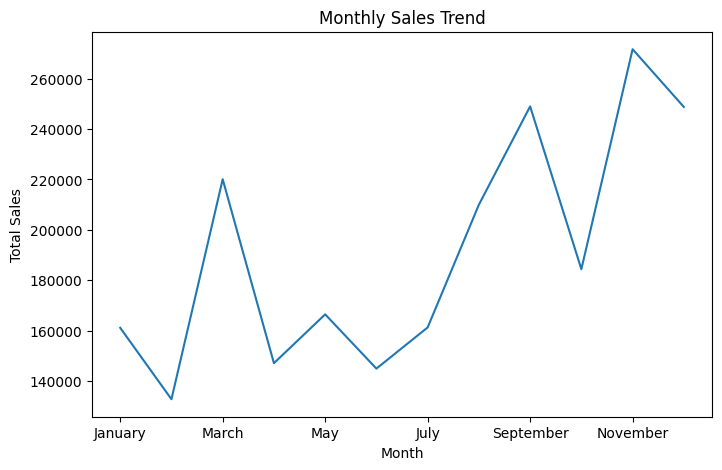

In [32]:
import matplotlib.pyplot as plt

df['MonthName'] = df['Order Date'].dt.month_name()

monthly_sales = df.groupby('MonthName')['Sales'].sum()
monthly_sales = monthly_sales.reindex([
    'January','February','March','April','May','June',
    'July','August','September','October','November','December'
])

plt.figure(figsize=(8,5))
monthly_sales.plot()

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.show()

### Analysis: Sales Over Time



This line chart shows how total sales vary across different months.

Key Insights:
- Sales fluctuate over time, indicating possible seasonal trends
- Certain months show higher sales performance

Business Insight:
Understanding monthly trends helps businesses plan promotions and inventory based on seasonal demand.

 ### 2. Region-wise Sales

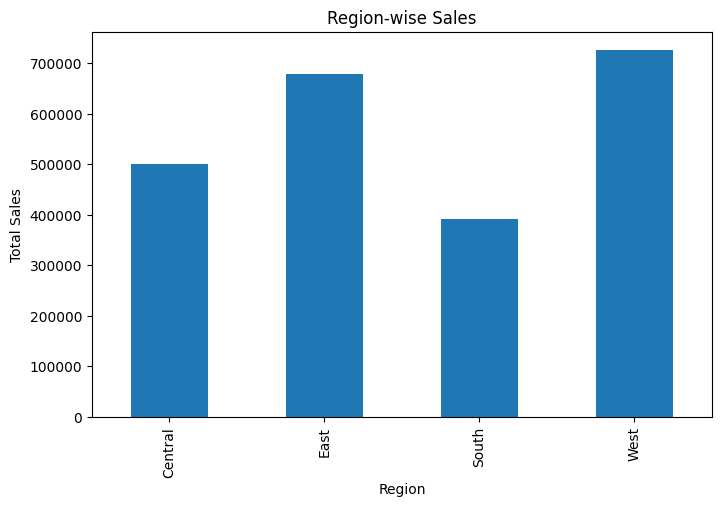

In [26]:
region_sales = df.groupby('Region')['Sales'].sum()

plt.figure(figsize=(8,5))
region_sales.plot(kind='bar')

plt.title("Region-wise Sales")
plt.xlabel("Region")
plt.ylabel("Total Sales")

plt.show()

### Analysis: Region-wise Sales



This bar chart compares total sales across different regions.

Key Insights:
- Some regions generate significantly higher revenue than others
- Sales performance varies by location

Business Insight:
High-performing regions should be prioritized for marketing and inventory expansion.

### 3. Top 10 Products

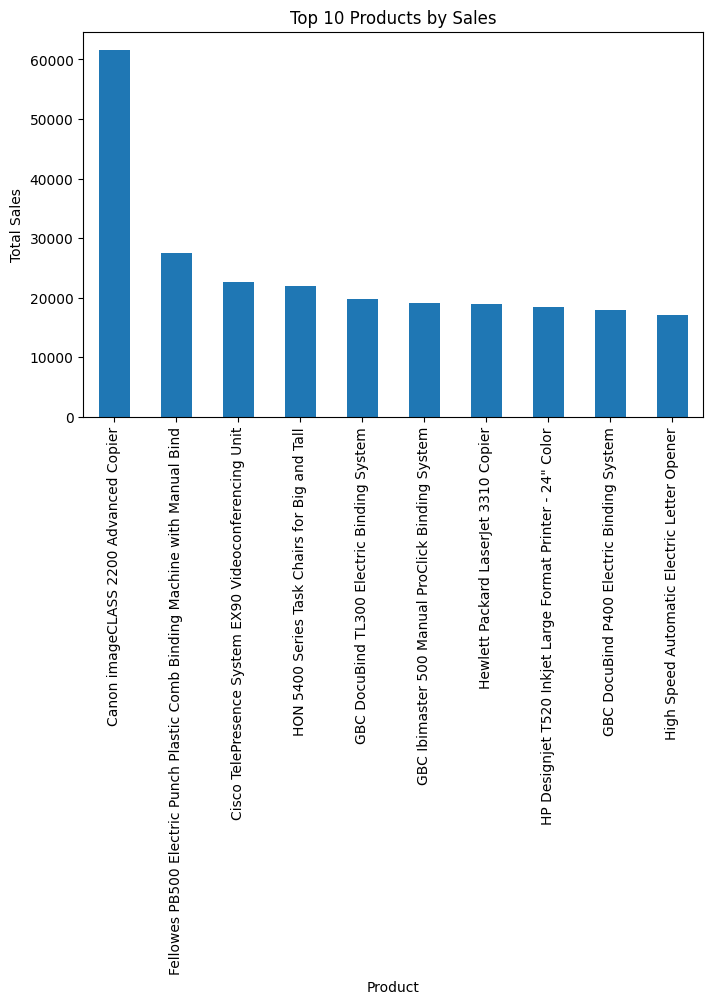

In [31]:
top_products = df.groupby('Product_Name')['Sales'].sum().nlargest(10)

plt.figure(figsize=(8,5))
top_products.plot(kind='bar')

plt.title("Top 10 Products by Sales")
plt.xlabel("Product")
plt.ylabel("Total Sales")

plt.xticks(rotation=90)

plt.show()

### Analysis: Top 10 Products



This chart highlights the top 10 products contributing the most to total revenue.

Key Insights:
- A small number of products drive a large portion of sales
- There is a clear difference between top and lower-performing products

Business Insight:
Focusing on high-performing products can significantly boost overall revenue.

## Final Insights

- Sales vary significantly across months indicating seasonal trends  
- Certain regions consistently outperform others  
- A small number of products contribute most to revenue  

## Recommendations

- Focus marketing on high-performing products  
- Increase stock in top regions  
- Plan campaigns based on peak sales months  